### Graph Partitioning Demo with Visualization
This example demonstrates a complete end-to-end graph partitioning experiment, including environment setup, model definition, synthetic graph generation, optimization, and result visualization.


#### Environment Setup and Model Definition

In [2]:
import sys
from pathlib import Path
current = Path.cwd()
root_path = current.parents[3]  
sys.path.append(str(root_path))
import torch
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from src import (
    generate_data, 
    loss_partitioning_onehot_qubo, 
    run_qubo, 
    get_device,
    init,
    DirectProbModel
)

print("PyTorch version:", torch.__version__)

PyTorch version: 1.13.1


#### Define the direct probability model:

In [6]:
class DirectProbModel(torch.nn.Module):
    def __init__(self, num_nodes, num_classes):
        super().__init__()
        # 'h' stores the potential of each node belonging to each class
        self.h = torch.nn.Parameter(torch.randn(num_nodes, num_classes))

    def forward(self, X=None, *args, **kwargs):
        # Your core logic: Softmax to normalize probabilities
        p = torch.softmax(self.h, dim=-1)
        return (p,)

print("Model definition completed.")

Model definition completed.


#### Graph Generation and Optimization
Initialize device and generate a synthetic graph:

In [3]:
init(reproducibility=True) 
device = get_device()

graph = generate_data(type="graph", v=10, e=18, seed=42).to(device)

print(f"nodes: {graph.num_v}")
print(f"edges: {graph.e[0]}")

[WARNING] You have enabled the reproducibility feature, which uses a deterministic non-optimized algorithm, greatly affecting the running efficiency
[INFO] Using CUDA device: NVIDIA GeForce RTX 3090 (Index: 0)


nodes: 10
edges: [(0, 1), (3, 8), (0, 4), (3, 4), (1, 5), (1, 8), (0, 6), (2, 3), (7, 9), (4, 5), (8, 9), (2, 6), (5, 9), (3, 6), (1, 6), (0, 8), (1, 9), (7, 8)]


#### Initialize the model and define dynamic weight scheduling:

In [7]:
# Initialize the model
net = DirectProbModel(graph.num_v, 2).to(device)

# Define your dynamic weight scheduling (Lambda functions)
# These adjust the balance vs. cut-size priority over time
gini_cof_lambda = lambda e, n: (-800 + 0.25 * e) / 1000
obj_cof_lambda = lambda e, n: e / 900
cons_cof_lambda = lambda e, n: e / 1000 + e * 0.001

print(f"Starting optimization on {device}...")
loss, outs, res = run_qubo(
    type="partitioning", 
    net=net, 
    X=torch.randn(1, 1).to(device),
    graph=graph, 
    num_epochs=3000, 
    loss_func=loss_partitioning_onehot_qubo,
    lr=0.1, 
    opt='AdamW', 
    gini_cof_lambda=gini_cof_lambda,
    obj_cof_lambda=obj_cof_lambda,
    cons_cof_lambda=cons_cof_lambda,
    evaluate=True
)

# Extract final classification labels (handle tuple and convert to Numpy)
prob_matrix = outs[0] if isinstance(outs, tuple) else outs
final_labels = torch.argmax(prob_matrix, dim=1).cpu().numpy()

print(f"Training Complete! Cuts: {res['cuts']}, Balance: {res['blce']}")

Starting optimization on cuda:0...


 36%|███▌      | 1087/3000 [00:03<00:03, 511.49it/s]

Epoch: 1000 | partitoning Loss: 10.01 | balance Loss: 0.02 | gini Loss: 0.20


 70%|███████   | 2100/3000 [00:05<00:01, 686.77it/s]

Epoch: 2000 | partitoning Loss: 10.00 | balance Loss: 0.00 | gini Loss: 0.07


100%|██████████| 3000/3000 [00:06<00:00, 494.26it/s]

Epoch: 3000 | partitoning Loss: 10.00 | balance Loss: 0.00 | gini Loss: 0.01
+------------[Evaluation Result]------------+
Cuts: 5
Blce: [5 5]
Not converged nodes: 0
+-------------------------------------------+
Training Complete! Cuts: 5, Balance: [5 5]


#### Visualization of Partitioning Results
Define a function to plot the partitioned graph:

[DEBUG] Loaded backend module://matplotlib_inline.backend_inline version unknown.
[DEBUG] Loaded backend module://matplotlib_inline.backend_inline version unknown.
[DEBUG] findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
[DEBUG] findfont: score(FontEntry(fname='/home/guohao/miniconda3/envs/kgrouping/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG] findfont: score(FontEntry(fname='/home/guohao/miniconda3/envs/kgrouping/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf', name='DejaVu Sans Mono', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
[DEBUG] findfont: score(FontEntry(fname='/home/guohao/miniconda3/envs/kgrouping/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSans.ttf', name='DejaVu Sans', style='normal

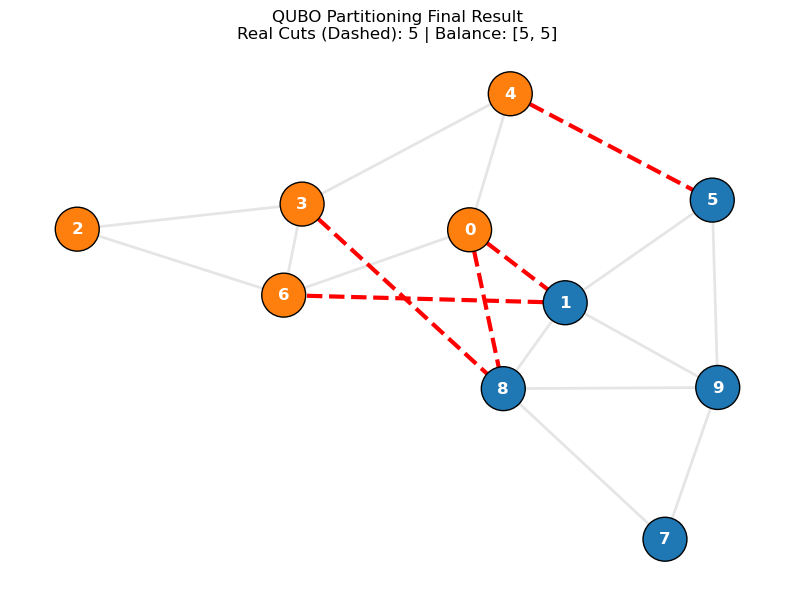

In [8]:
def visualize_final_result(graph, labels, res):
    G = nx.Graph()
    edge_data = graph.e[0]
    edges_np = edge_data.cpu().numpy() if torch.is_tensor(edge_data) else np.array(edge_data)
    if edges_np.ndim == 2 and edges_np.shape[0] == 2:
        edges_np = edges_np.T
    num_nodes = len(labels)
    G.add_nodes_from(range(num_nodes))
    G.add_edges_from(edges_np)
    cut_edges = []
    inner_edges = []
    for u, v in G.edges():
        if labels[int(u)] != labels[int(v)]:
            cut_edges.append((u, v))
        else:
            inner_edges.append((u, v))
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(10, 7))
    
    node_colors = ['#FF7F0E' if labels[i] == 0 else '#1F77B4' for i in range(num_nodes)]

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1000, edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_color='white', font_weight='bold')
    nx.draw_networkx_edges(G, pos, edgelist=inner_edges, width=2, alpha=0.2, edge_color='gray')
    if cut_edges:
        nx.draw_networkx_edges(G, pos, edgelist=cut_edges, width=3, edge_color='red', style='dashed')
    actual_cut_count = len(cut_edges)
    balance_counts = np.bincount(labels).tolist()
    
    plt.title(f"QUBO Partitioning Final Result\nReal Cuts (Dashed): {actual_cut_count} | Balance: {balance_counts}")
    plt.axis('off')
    plt.show()

visualize_final_result(graph, final_labels, res)